# Task penetration

This notebook constructs task-level penetration measures by combining observed Anthropic task usage, automation intensity, and Eloundou exposure scores.

## Core idea

The objective is to identify tasks that are:

1. meaningfully present in observed LLM usage  
2. sufficiently exposed according to Eloundou  
3. more automation-oriented rather than purely assistive

## Data used

We combine:

- Claude AI task usage
- 1P API task usage
- automation shares from `automation_vs_augmentation_by_task.csv`
- exposure scores from `full_labelset_new.tsv`

We define:

- `AutoShare = directive + feedback_loop`

## Usage construction

For each task, total usage is:

$$
\text{WorkUsage}_t = \text{ClaudeWorkUsage}_t + \text{APIUsage}_t
$$

Claude usage is extracted from work-related task occurrences when the use-case split is available.  
API usage is always taken from all task-level occurrences.

## Penetration formula

For each task \( t \), the penetration score is:

$$
\tilde r_t
=
\mathbf{1}\{\text{WorkUsage}_t \ge 100\}
\times
\mathbf{1}\{\beta_t \ge 0.5\}
\times
\alpha_t
$$

This means a task only receives positive penetration if:

- total observed usage is at least 100
- the task has exposure at or above 0.5

## Automation adjustment

The adjustment term is:

$$
\alpha_t
=
\frac{1}{2}
+
\frac{1}{2}
\cdot
\frac{
\text{ClaudeWorkUsage}_t \cdot \text{AutoShare}_t + \text{APIUsage}_t
}{
\text{ClaudeWorkUsage}_t + \text{APIUsage}_t
}
$$

This upweights tasks that are used in more automative ways.

## Measures produced

The file keeps the original penetration column and adds two new variants:

- `penetration_beta`
- `penetration_beta_new`

They use the same formula, but differ in the exposure column used:

- `penetration_beta` uses `beta`
- `penetration_beta_new` uses `beta_new`

## Output

The final dataset is saved to:

`Anthropic/task_penetration.csv`

The notebook then compares:

- `penetration`
- `penetration_beta`
- `penetration_beta_new`

using summary statistics, correlations, and task-level differences.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# Paths
# ============================================================
BASE = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")

ANTHROPIC_DIR = BASE / "Anthropic"
ELOUNDOU_FILE = BASE / "Eloundou_New" / "full_labelset_new.tsv"
AUTOMATION_FILE = ANTHROPIC_DIR / "automation_vs_augmentation_by_task.csv"
OUTPUT_FILE = ANTHROPIC_DIR / "task_penetration.csv"

CLAUDE_FILES = [
    ANTHROPIC_DIR / "aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv",
    ANTHROPIC_DIR / "aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv",
    ANTHROPIC_DIR / "aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv",
]

API_FILES = [
    ANTHROPIC_DIR / "aei_raw_1p_api_2025-08-04_to_2025-08-11.csv",
    ANTHROPIC_DIR / "aei_raw_1p_api_2025-11-13_to_2025-11-20 (1).csv",
    ANTHROPIC_DIR / "aei_raw_1p_api_2026-02-05_to_2026-02-12.csv",
]

GEO_ID = "GLOBAL"
USE_CASE = "work"

# ============================================================
# Helper: exact extraction logic from your plotting code
# ============================================================
def extract_task_counts(path: Path, geo_id: str, source_kind: str, use_case: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if "platform_and_product" in df.columns:
        if source_kind == "claude":
            df = df[df["platform_and_product"].astype(str).str.startswith("Claude AI")].copy()
        elif source_kind == "api":
            df = df[df["platform_and_product"] == "1P API"].copy()

    if "geo_id" in df.columns:
        df = df[df["geo_id"] == geo_id].copy()

    if source_kind == "claude":
        has_uc = (df["facet"] == "onet_task::use_case").any()

        if has_uc:
            out = df[
                (df["facet"] == "onet_task::use_case") &
                (df["variable"] == "onet_task_use_case_count") &
                (df["cluster_name"].astype(str).str.endswith(f"::{use_case}"))
            ].copy()

            out["task"] = out["cluster_name"].astype(str).str.rsplit("::", n=1).str[0]
            out = out.rename(columns={"value": "count"})[["task", "count"]]
        else:
            out = df[
                (df["facet"] == "onet_task") &
                (df["variable"] == "onet_task_count")
            ].copy()

            out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]
    else:
        out = df[
            (df["facet"] == "onet_task") &
            (df["variable"] == "onet_task_count")
        ].copy()

        out = out.rename(columns={"cluster_name": "task", "value": "count"})[["task", "count"]]

    out["task"] = out["task"].astype(str).str.strip().str.lower()
    out["count"] = pd.to_numeric(out["count"], errors="coerce")
    out = out.dropna(subset=["task", "count"]).copy()
    out = out[~out["task"].isin(["not_classified", "none"])].copy()
    out = out.groupby("task", as_index=False)["count"].sum()

    return out

def load_and_pool_usage(files, source_kind, geo_id, use_case, out_col):
    parts = []
    for f in files:
        parts.append(extract_task_counts(f, geo_id, source_kind, use_case))
    df = pd.concat(parts, ignore_index=True)
    df = df.groupby("task", as_index=False)["count"].sum()
    df = df.rename(columns={"count": out_col})
    return df

# ============================================================
# 1. Load existing file and preserve it
# ============================================================
existing = pd.read_csv(OUTPUT_FILE)

# Keep first two columns exactly unchanged
first_two_cols = list(existing.columns[:2])

# We assume the first column is the original task description
task_desc_col = first_two_cols[0]

existing["_task_key"] = existing[task_desc_col].astype(str).str.strip().str.lower()

# ============================================================
# 2. Load usage
# ============================================================
claude_usage = load_and_pool_usage(
    CLAUDE_FILES, "claude", GEO_ID, USE_CASE, "claude_work_usage"
)

api_usage = load_and_pool_usage(
    API_FILES, "api", GEO_ID, USE_CASE, "api_usage"
)

# ============================================================
# 3. Load automation
# ============================================================
auto_df = pd.read_csv(AUTOMATION_FILE)

task_col_auto = None
for c in auto_df.columns:
    if c.lower() in ["task_name", "task", "task_title", "title", "label"]:
        task_col_auto = c
        break

if task_col_auto is None:
    raise ValueError(f"Could not find task column in automation file. Columns: {list(auto_df.columns)}")

auto_df = auto_df[[task_col_auto, "directive", "feedback_loop"]].copy()
auto_df = auto_df.rename(columns={task_col_auto: "task"})
auto_df["task"] = auto_df["task"].astype(str).str.strip().str.lower()
auto_df["directive"] = pd.to_numeric(auto_df["directive"], errors="coerce").fillna(0)
auto_df["feedback_loop"] = pd.to_numeric(auto_df["feedback_loop"], errors="coerce").fillna(0)
auto_df["auto_share"] = (auto_df["directive"] + auto_df["feedback_loop"]).clip(0, 1)
auto_df = auto_df.groupby("task", as_index=False)["auto_share"].max()

# ============================================================
# 4. Load beta / beta_new
# ============================================================
df_eloundou = pd.read_csv(ELOUNDOU_FILE, sep="\t", low_memory=False)

beta_df = (
    df_eloundou[["Task", "beta", "beta_new"]]
    .drop_duplicates(subset=["Task"])
    .rename(columns={"Task": "task"})
)

beta_df["task"] = beta_df["task"].astype(str).str.strip().str.lower()
beta_df["beta"] = pd.to_numeric(beta_df["beta"], errors="coerce")
beta_df["beta_new"] = pd.to_numeric(beta_df["beta_new"], errors="coerce")

# ============================================================
# 5. Compute new penetration columns only
# ============================================================
calc = (
    existing[["_task_key"]]
    .drop_duplicates()
    .rename(columns={"_task_key": "task"})
    .merge(beta_df, on="task", how="left")
    .merge(claude_usage, on="task", how="left")
    .merge(api_usage, on="task", how="left")
    .merge(auto_df, on="task", how="left")
)

calc["claude_work_usage"] = calc["claude_work_usage"].fillna(0.0)
calc["api_usage"] = calc["api_usage"].fillna(0.0)
calc["auto_share"] = calc["auto_share"].fillna(0.0)

calc["work_usage"] = calc["claude_work_usage"] + calc["api_usage"]

numerator = calc["claude_work_usage"] * calc["auto_share"] + calc["api_usage"]
denominator = calc["work_usage"]

share_term = np.where(denominator > 0, numerator / denominator, 0.0)
calc["alpha"] = 0.5 + 0.5 * share_term

calc["penetration_beta"] = (
    (calc["work_usage"] >= 100).astype(int) *
    (calc["beta"] >= 0.5).fillna(False).astype(int) *
    calc["alpha"]
)

calc["penetration_beta_new"] = (
    (calc["work_usage"] >= 100).astype(int) *
    (calc["beta_new"] >= 0.5).fillna(False).astype(int) *
    calc["alpha"]
)

calc = calc[["task", "penetration_beta", "penetration_beta_new"]].rename(columns={"task": "_task_key"})

# ============================================================
# 6. Merge back without changing the existing structure
# ============================================================
out = existing.copy()

# remove old versions only if they already exist
for col in ["penetration_beta", "penetration_beta_new"]:
    if col in out.columns:
        out = out.drop(columns=[col])

out = out.merge(calc, on="_task_key", how="left")

# drop helper key
out = out.drop(columns=["_task_key"])

# ============================================================
# 7. Save back to the same file
# ============================================================
out.to_csv(OUTPUT_FILE, index=False)

print(f"Saved updated file to: {OUTPUT_FILE}")
print("First two columns preserved exactly:", first_two_cols)
print("Added columns: penetration_beta, penetration_beta_new")

Saved updated file to: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Anthropic/task_penetration.csv
First two columns preserved exactly: ['task', 'penetration']
Added columns: penetration_beta, penetration_beta_new


Rows: 18118
Missing values:
penetration             1
penetration_beta        0
penetration_beta_new    0
dtype: int64

=== Summary statistics ===
                        count      mean       std  min  median  max  \
penetration           18117.0  0.071065  0.240720  0.0     0.0  1.0   
penetration_beta      18118.0  0.065635  0.224088  0.0     0.0  1.0   
penetration_beta_new  18118.0  0.058283  0.212762  0.0     0.0  1.0   

                      nonzero_share  zero_share  
penetration                0.081300    0.918644  
penetration_beta           0.080528    0.919472  
penetration_beta_new       0.071034    0.928966  

=== Pearson correlation ===
                      penetration  penetration_beta  penetration_beta_new
penetration              1.000000          0.922798              0.862606
penetration_beta         0.922798          1.000000              0.930199
penetration_beta_new     0.862606          0.930199              1.000000

=== Spearman correlation ===
             

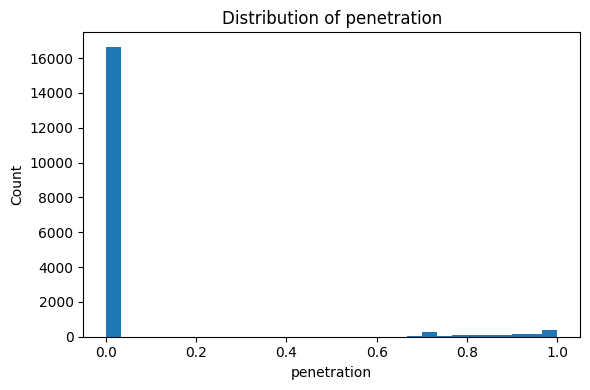

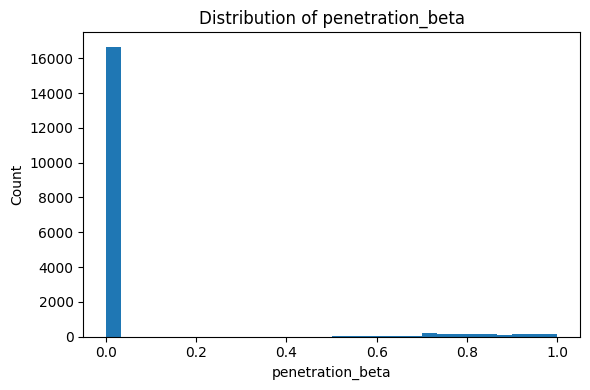

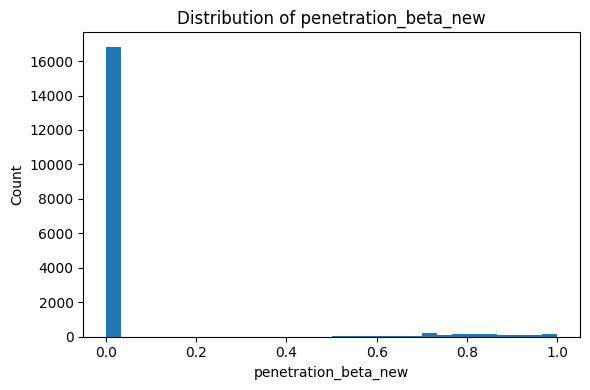

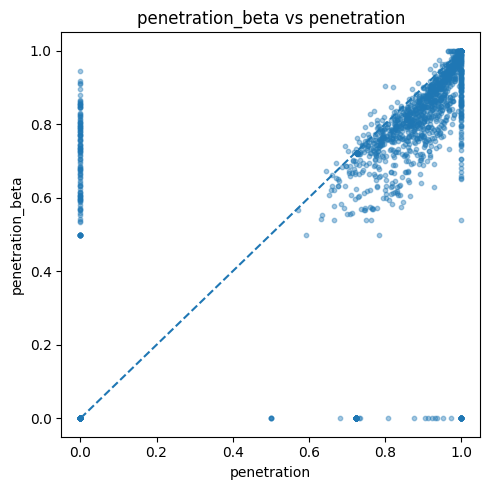

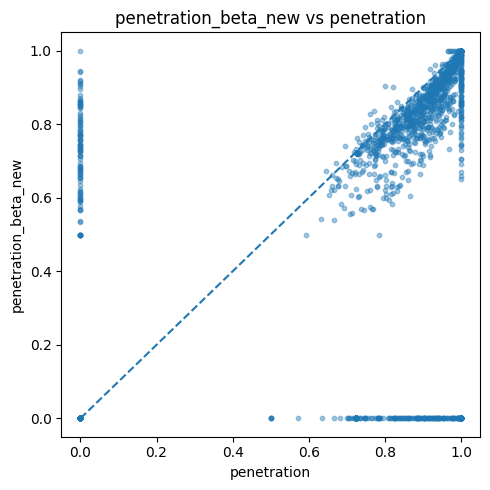

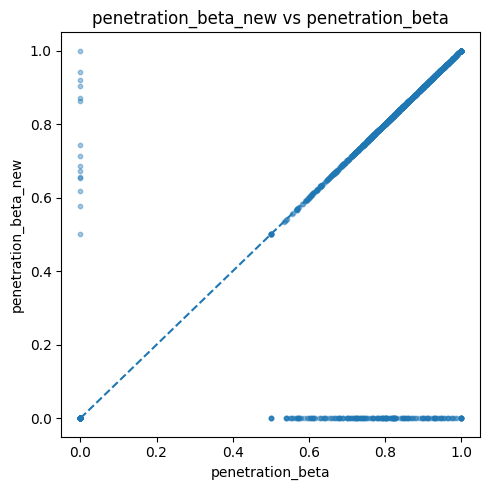

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load file
# ============================================================
FILE = "/Users/nicobagnoli/Documents/PYTHON/SMP500/Anthropic/task_penetration.csv"

df = pd.read_csv(FILE)

cols = ["penetration", "penetration_beta", "penetration_beta_new"]

for c in cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Rows:", len(df))
print("Missing values:")
print(df[cols].isna().sum())
print()

# ============================================================
# 1. Basic descriptive statistics
# ============================================================
summary = df[cols].agg(["count", "mean", "std", "min", "median", "max"]).T
summary["nonzero_share"] = (df[cols] > 0).mean().values
summary["zero_share"] = (df[cols] == 0).mean().values

print("=== Summary statistics ===")
print(summary)
print()

# ============================================================
# 2. Pairwise correlations
# ============================================================
corr_pearson = df[cols].corr(method="pearson")
corr_spearman = df[cols].corr(method="spearman")

print("=== Pearson correlation ===")
print(corr_pearson)
print()

print("=== Spearman correlation ===")
print(corr_spearman)
print()

# ============================================================
# 3. Differences between old and new penetration measures
# ============================================================
df["diff_old_vs_beta"] = df["penetration_beta"] - df["penetration"]
df["diff_old_vs_beta_new"] = df["penetration_beta_new"] - df["penetration"]
df["diff_beta_vs_beta_new"] = df["penetration_beta_new"] - df["penetration_beta"]

diff_cols = ["diff_old_vs_beta", "diff_old_vs_beta_new", "diff_beta_vs_beta_new"]

diff_summary = df[diff_cols].agg(["mean", "std", "min", "median", "max"]).T
print("=== Difference summaries ===")
print(diff_summary)
print()

# ============================================================
# 4. Share of exact agreement
# ============================================================
agreement = {
    "old == beta": (df["penetration"] == df["penetration_beta"]).mean(),
    "old == beta_new": (df["penetration"] == df["penetration_beta_new"]).mean(),
    "beta == beta_new": (df["penetration_beta"] == df["penetration_beta_new"]).mean(),
}

print("=== Exact agreement share ===")
for k, v in agreement.items():
    print(f"{k}: {v:.3%}")
print()

# ============================================================
# 5. Largest disagreements
# ============================================================
print("=== Top 20 tasks: biggest |penetration_beta - penetration| ===")
top_old_beta = (
    df.loc[:, ["task", "penetration", "penetration_beta", "penetration_beta_new", "diff_old_vs_beta"]]
    .assign(abs_diff=lambda x: x["diff_old_vs_beta"].abs())
    .sort_values("abs_diff", ascending=False)
    .head(20)
)
print(top_old_beta)
print()

print("=== Top 20 tasks: biggest |penetration_beta_new - penetration| ===")
top_old_beta_new = (
    df.loc[:, ["task", "penetration", "penetration_beta", "penetration_beta_new", "diff_old_vs_beta_new"]]
    .assign(abs_diff=lambda x: x["diff_old_vs_beta_new"].abs())
    .sort_values("abs_diff", ascending=False)
    .head(20)
)
print(top_old_beta_new)
print()

print("=== Top 20 tasks: biggest |penetration_beta_new - penetration_beta| ===")
top_beta_beta_new = (
    df.loc[:, ["task", "penetration", "penetration_beta", "penetration_beta_new", "diff_beta_vs_beta_new"]]
    .assign(abs_diff=lambda x: x["diff_beta_vs_beta_new"].abs())
    .sort_values("abs_diff", ascending=False)
    .head(20)
)
print(top_beta_beta_new)
print()

# ============================================================
# 6. Nonzero overlap
# ============================================================
nonzero_overlap = pd.DataFrame({
    "old_nonzero": df["penetration"] > 0,
    "beta_nonzero": df["penetration_beta"] > 0,
    "beta_new_nonzero": df["penetration_beta_new"] > 0,
})

print("=== Nonzero counts ===")
print(nonzero_overlap.sum())
print()

print("=== Nonzero overlap table: old vs beta ===")
print(pd.crosstab(nonzero_overlap["old_nonzero"], nonzero_overlap["beta_nonzero"]))
print()

print("=== Nonzero overlap table: old vs beta_new ===")
print(pd.crosstab(nonzero_overlap["old_nonzero"], nonzero_overlap["beta_new_nonzero"]))
print()

print("=== Nonzero overlap table: beta vs beta_new ===")
print(pd.crosstab(nonzero_overlap["beta_nonzero"], nonzero_overlap["beta_new_nonzero"]))
print()

# ============================================================
# 7. Histograms
# ============================================================
for c in cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Distribution of {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Scatter plots
# ============================================================
pairs = [
    ("penetration", "penetration_beta"),
    ("penetration", "penetration_beta_new"),
    ("penetration_beta", "penetration_beta_new"),
]

for x, y in pairs:
    plt.figure(figsize=(5, 5))
    plt.scatter(df[x], df[y], alpha=0.4, s=10)
    lims = [
        min(df[x].min(), df[y].min()),
        max(df[x].max(), df[y].max())
    ]
    plt.plot(lims, lims, linestyle="--")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{y} vs {x}")
    plt.tight_layout()
    plt.show()